# Dos tercios del deshielo extra de la Antártida vienen del propio deshielo

Una simulación de la Antártida completa bajo el peor escenario climático del IPCC (SSP5-8.5) descompone el aumento del derretimiento basal en dos piezas: lo que mete el calentamiento del océano directamente, y lo que añade el propio agua de deshielo al volver a la cavidad. En el modelo, el 66% del aumento total viene de la segunda pieza.

**Paper:** [10.1038/s41561-026-01975-6](https://doi.org/10.1038/s41561-026-01975-6) · Nature Geoscience, 2026-05-15 · Youngs et al.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-15-antartida-feedbacks-deshielo/notebook.ipynb)

## El contexto

Cuando una plataforma de hielo flotante se derrite por abajo, el agua dulce y fría que sale modifica el océano local. Eso cambia las corrientes, cambia la salinidad, y por lo tanto cambia cuánta agua cálida llega de vuelta a la cavidad. Es un sistema que se retroalimenta.

El paper corre 3 simulaciones con [MITgcm](https://mitgcm.readthedocs.io/) — un modelo oceánico con plataformas de hielo interactivas alrededor de toda la Antártida:

1. **Control preindustrial** — clima del 1850.
2. **SSP5-8.5** — el peor escenario climático del IPCC (forzado con [GFDL-CM4](https://www.gfdl.noaa.gov/coupled-physics/)).
3. **SSP5-8.5 con derretimiento fijo** — calentamiento sin permitir que el feedback opere.

La diferencia entre 2 y 3 aísla **cuánto del aumento es por el feedback** y cuánto es respuesta directa al calentamiento. Hicieron eso para 10 sectores de la Antártida.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FRACCION_OBJETIVO = 0.66           # "Two-thirds" del abstract
FUENTE = 'Fuente: Youngs et al. (2026), Nature Geoscience | Datos: Zenodo 17992455'

COLOR_FEEDBACK = '#DC2626'         # Feedback (lo nuevo del paper)
COLOR_FORZADO  = '#2563EB'         # Respuesta directa al calentamiento
COLOR_TOTAL    = '#7C3AED'         # Suma de ambos
COLOR_PROTEGE  = '#059669'         # Sectores donde el feedback REDUCE el deshielo
COLOR_GRIS     = '#BBBBBB'

# ─── Imports ───
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── Estilo CaM (local → fallback GitHub raw) ───
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ─── Cargar los 3 datasets ───
melt = pd.read_csv('datos/melt_change_por_sector.csv')
temp = pd.read_csv('datos/temperatura_cambio_por_sector.csv')
sali = pd.read_csv('datos/salinidad_cambio_por_sector.csv')

# Resumen
total = melt['total_change_gt_yr'].sum()
forzado = melt['forced_response_gt_yr'].sum()
feedback = melt['melt_feedback_gt_yr'].sum()

print(f"10 sectores cargados")
print(f"Cambio total circumpolar: {total:>7.1f} Gt/año")
print(f"  Respuesta forzada:      {forzado:>7.1f} Gt/año ({forzado/total*100:.0f}%)")
print(f"  Feedback del deshielo:  {feedback:>7.1f} Gt/año ({feedback/total*100:.0f}%)")

10 sectores cargados
Cambio total circumpolar:   804.6 Gt/año
  Respuesta forzada:        273.6 Gt/año (34%)
  Feedback del deshielo:    531.1 Gt/año (66%)


## Aquí está

La descomposición sector por sector.

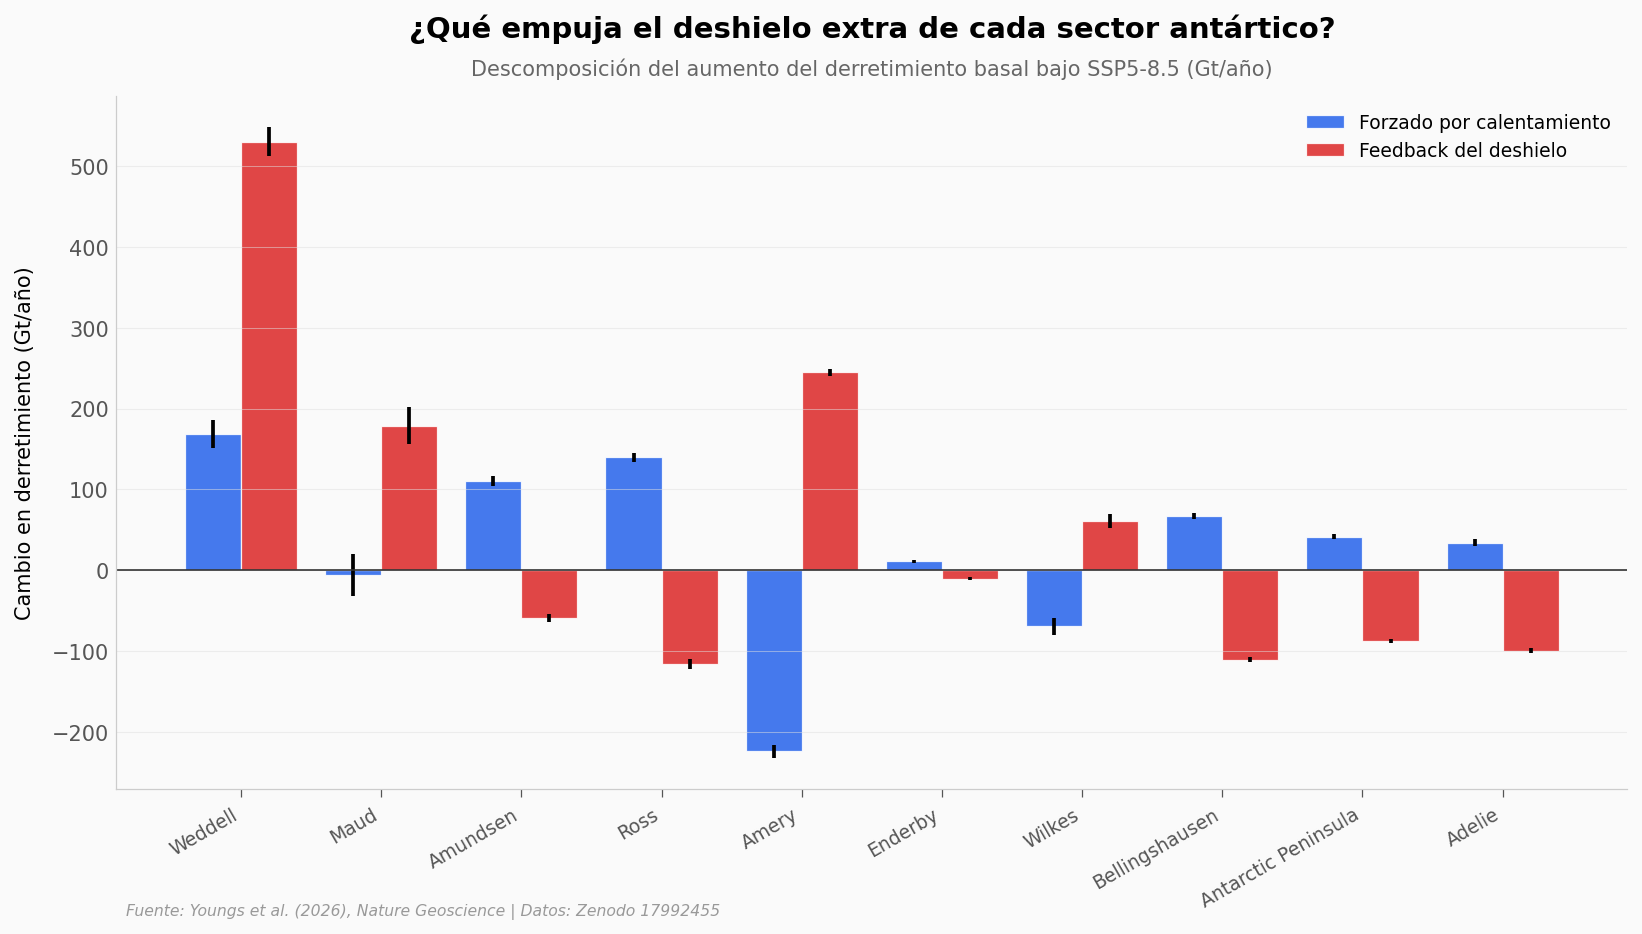

In [2]:
# Ordenar sectores por cambio total descendente
df = melt.sort_values('total_change_gt_yr', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(df))
w = 0.4

# Barras: forzado (izquierda) y feedback (derecha)
ax.bar(x - w/2, df['forced_response_gt_yr'], w,
       yerr=df['forced_se_gt_yr'], color=COLOR_FORZADO, alpha=0.85,
       edgecolor='white', linewidth=0.6, label='Forzado por calentamiento')
ax.bar(x + w/2, df['melt_feedback_gt_yr'], w,
       yerr=df['feedback_se_gt_yr'], color=COLOR_FEEDBACK, alpha=0.85,
       edgecolor='white', linewidth=0.6, label='Feedback del deshielo')

# Línea cero + título
ax.axhline(0, color='#333333', linewidth=0.8)
ax.set_title('¿Qué empuja el deshielo extra de cada sector antártico?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Descomposición del aumento del derretimiento basal bajo SSP5-8.5 (Gt/año)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Etiquetas de sector
ax.set_xticks(x)
ax.set_xticklabels(df['sector'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Cambio en derretimiento (Gt/año)', fontsize=10)

# Leyenda dentro del plot (solo 2 series)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/01_descomposicion_por_sector.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:**

- En la simulación, Weddell es el sector dominante: aporta 698 Gt/año al aumento total — varias veces lo de cualquier otro sector. Dentro de Weddell, el feedback (rojo) explica la mayoría.
- Hay sectores donde las dos barras van en **direcciones opuestas**. Mira Amery: el calentamiento directo (azul) le REDUCE el deshielo, pero el feedback (rojo) lo compensa con creces. La señal neta queda positiva por la pieza que la mayoría de modelos climáticos ni siquiera tiene.
- Y hay sectores donde el feedback hace lo contrario: en Ross, Bellingshausen, Adelie y la Península, el feedback BAJA el deshielo respecto a lo que el calentamiento solo causaría. El agua dulce de los sectores densos viaja hacia el oeste y actúa como un escudo.

## Cuatro amplifican, seis protegen

El feedback no actúa igual en toda la Antártida. Es positivo en 4 sectores (amplifica el deshielo) y negativo en 6 (lo reduce). Veamos esa partición.

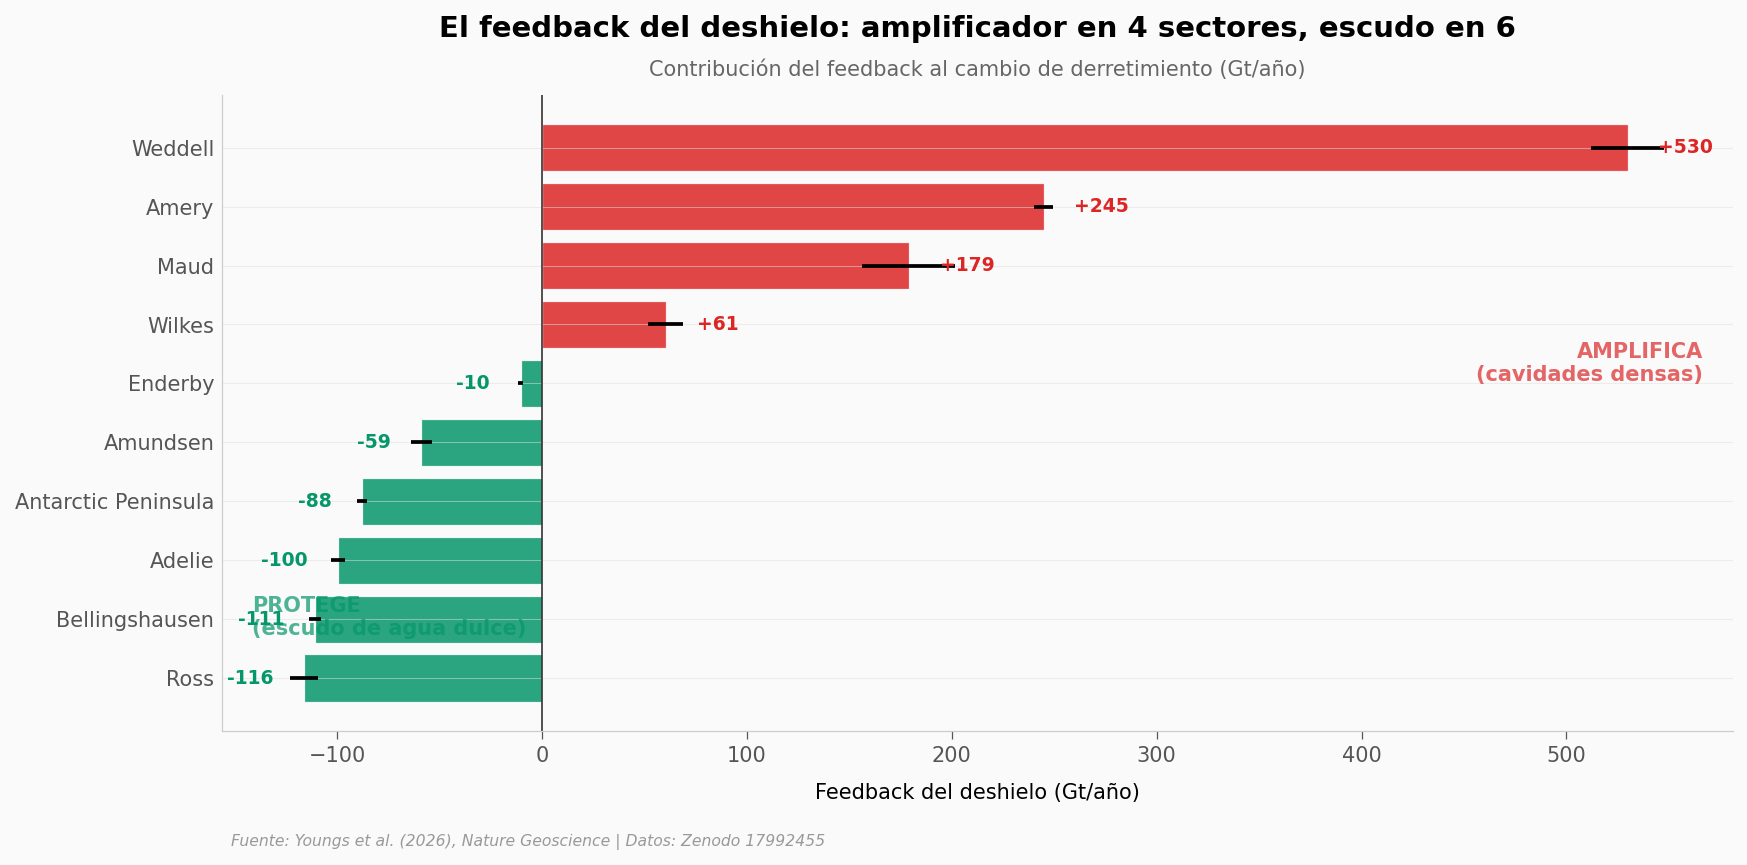

In [3]:
# Clasificar sectores por signo del feedback
df_fb = melt.sort_values('melt_feedback_gt_yr', ascending=False).reset_index(drop=True)
colors = [COLOR_FEEDBACK if v > 0 else COLOR_PROTEGE for v in df_fb['melt_feedback_gt_yr']]

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.barh(df_fb['sector'], df_fb['melt_feedback_gt_yr'],
               xerr=df_fb['feedback_se_gt_yr'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.6)

ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('El feedback del deshielo: amplificador en 4 sectores, escudo en 6',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Contribución del feedback al cambio de derretimiento (Gt/año)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Inline labels al final de cada barra
for i, (sector, val) in enumerate(zip(df_fb['sector'], df_fb['melt_feedback_gt_yr'])):
    color = COLOR_FEEDBACK if val > 0 else COLOR_PROTEGE
    offset = 15 if val > 0 else -15
    align = 'left' if val > 0 else 'right'
    ax.text(val + offset, i, f'{val:+.0f}', fontsize=9, fontweight='bold',
            color=color, ha=align, va='center')

ax.set_xlabel('Feedback del deshielo (Gt/año)', fontsize=10)
ax.invert_yaxis()  # Mayor amplificación arriba

# Anotación textual de las dos zonas
ax.text(0.98, 0.55, 'AMPLIFICA\n(cavidades densas)',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        color=COLOR_FEEDBACK, ha='right', alpha=0.7)
ax.text(0.02, 0.15, 'PROTEGE\n(escudo de agua dulce)',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        color=COLOR_PROTEGE, ha='left', alpha=0.7)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_feedback_por_signo.png', dpi=200, bbox_inches='tight')
plt.show()

## Por qué pasa esto

El paper propone un mecanismo dual:

- **En cavidades densas** (Weddell, Amery, Maud, Wilkes) el agua del fondo es muy salina. Cuando el océano se calienta, esa agua salina se vuelve más ligera, deja entrar agua cálida bajo la plataforma, y aumenta el derretimiento. Bucle positivo.
- **Aguas abajo** (Bellingshausen, Amundsen, Ross, Adelie, Península) llega el agua dulce que viajó desde las cavidades densas hacia el oeste. Esa agua dulce forma una capa flotante que obstruye las intrusiones cálidas. Bucle negativo.

Si esto es así, deberíamos ver dos firmas en los datos:

1. **Salinidad** que cae en todas partes (el deshielo añade agua dulce a todo).
2. **Temperatura** que sube por dos rutas distintas — fuerte donde domina el forzamiento directo, atenuada o vuelta donde domina el escudo del feedback.

Veamos.

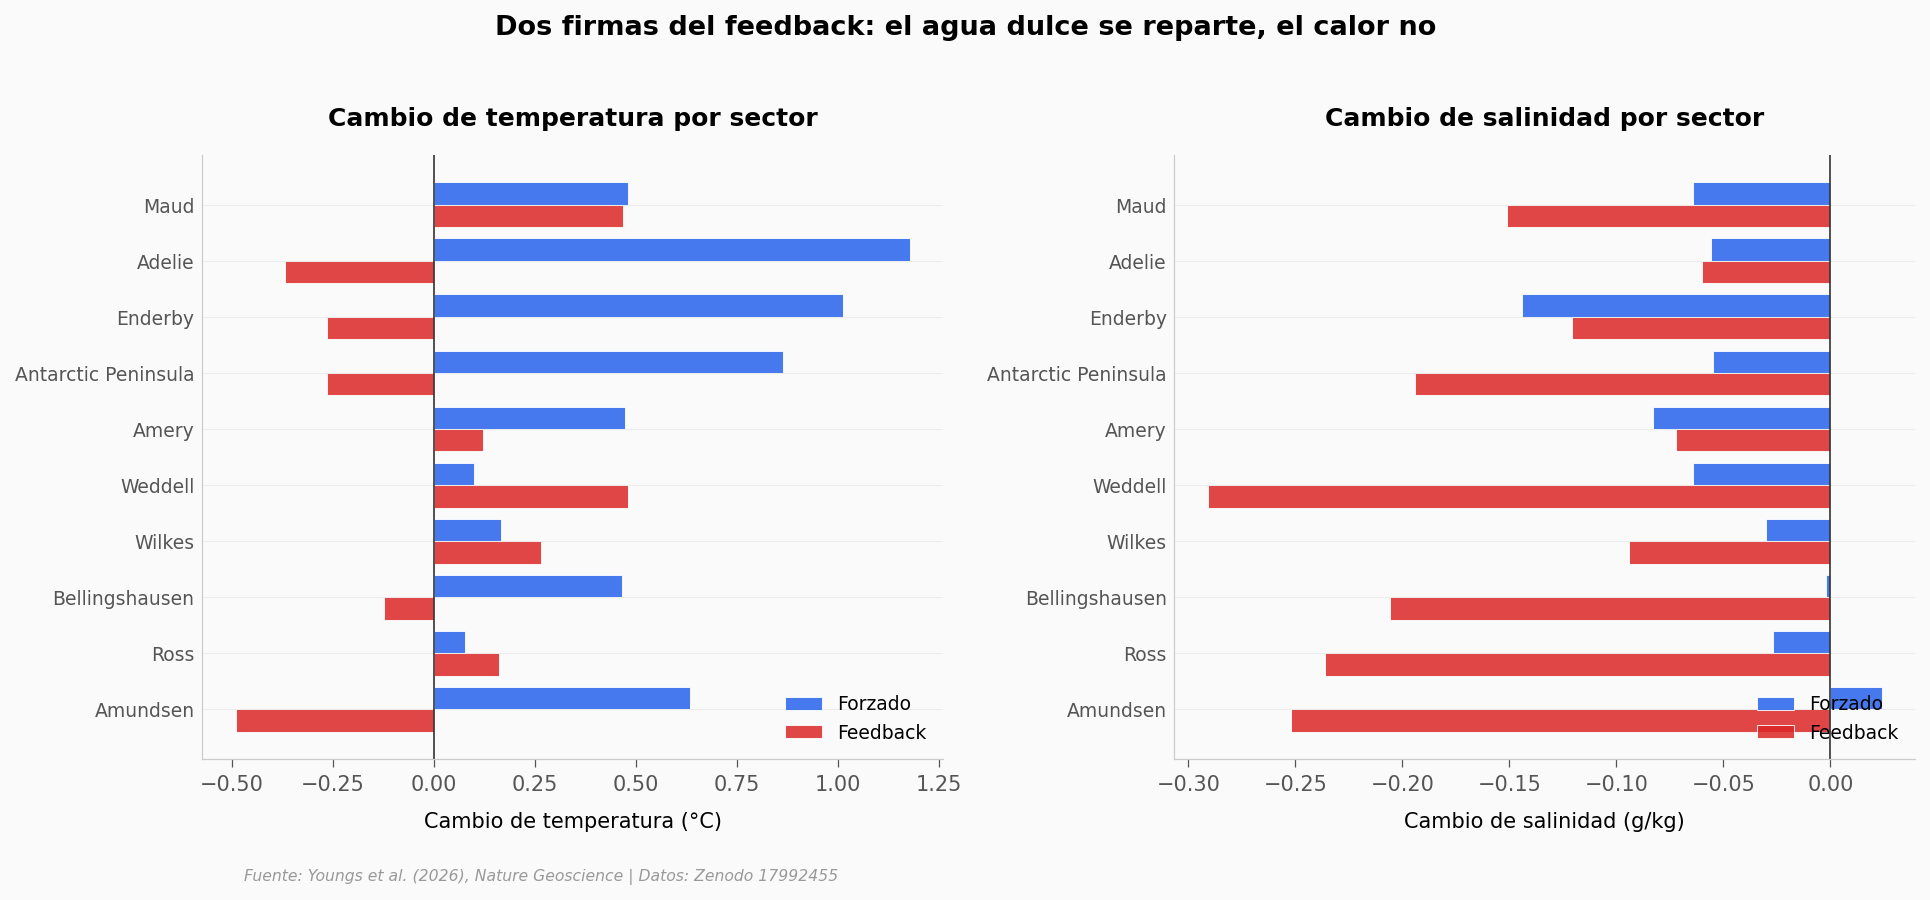

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Ordenar por cambio total de temperatura para visualizar
df_t = temp.sort_values('total_change_c', ascending=False).reset_index(drop=True)
df_s = sali.set_index('sector').loc[df_t['sector']].reset_index()

# Panel izquierdo: temperatura
y_t = np.arange(len(df_t))
ax1.barh(y_t - 0.2, df_t['forced_response_c'], 0.4,
         color=COLOR_FORZADO, alpha=0.85, edgecolor='white', linewidth=0.5,
         label='Forzado')
ax1.barh(y_t + 0.2, df_t['melt_feedback_c'], 0.4,
         color=COLOR_FEEDBACK, alpha=0.85, edgecolor='white', linewidth=0.5,
         label='Feedback')
ax1.axvline(0, color='#333333', linewidth=0.8)
ax1.set_yticks(y_t)
ax1.set_yticklabels(df_t['sector'], fontsize=9)
ax1.set_xlabel('Cambio de temperatura (°C)', fontsize=10)
ax1.set_title('Cambio de temperatura por sector',
              fontsize=12, fontweight='bold', pad=14)
ax1.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax1.invert_yaxis()

# Panel derecho: salinidad
y_s = np.arange(len(df_s))
ax2.barh(y_s - 0.2, df_s['forced_response_gkg'], 0.4,
         color=COLOR_FORZADO, alpha=0.85, edgecolor='white', linewidth=0.5,
         label='Forzado')
ax2.barh(y_s + 0.2, df_s['melt_feedback_gkg'], 0.4,
         color=COLOR_FEEDBACK, alpha=0.85, edgecolor='white', linewidth=0.5,
         label='Feedback')
ax2.axvline(0, color='#333333', linewidth=0.8)
ax2.set_yticks(y_s)
ax2.set_yticklabels(df_s['sector'], fontsize=9)
ax2.set_xlabel('Cambio de salinidad (g/kg)', fontsize=10)
ax2.set_title('Cambio de salinidad por sector',
              fontsize=12, fontweight='bold', pad=14)
ax2.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax2.invert_yaxis()

fig.suptitle('Dos firmas del feedback: el agua dulce se reparte, el calor no',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_temperatura_salinidad.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuánto pesa el feedback en el total?

Sumemos los 10 sectores y comparemos las dos piezas.

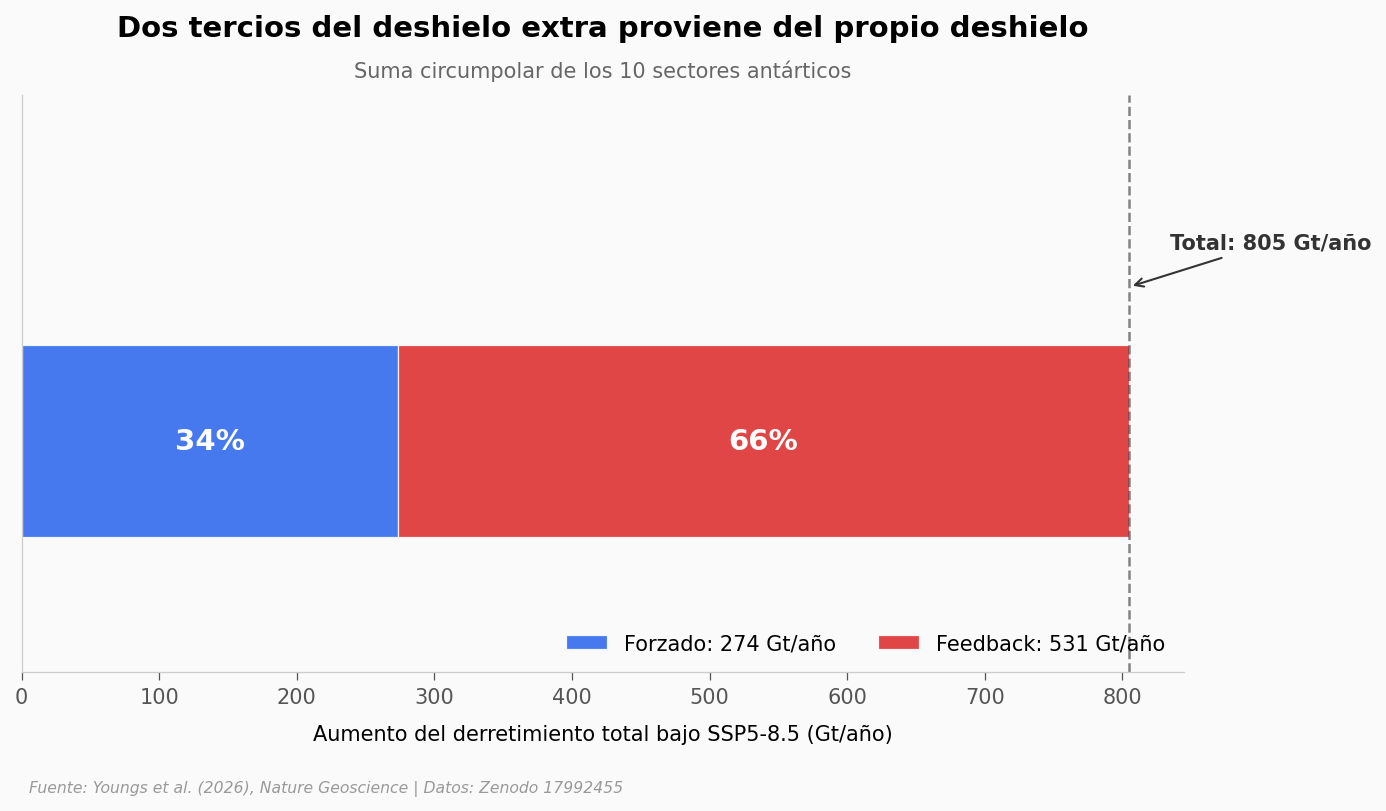


Fracción del feedback en el aumento total: 66.0%
Verbo del abstract: "two-thirds" → 66,7%. Verificado.


In [5]:
# Sumar 10 sectores
total = melt['total_change_gt_yr'].sum()
forzado = melt['forced_response_gt_yr'].sum()
feedback = melt['melt_feedback_gt_yr'].sum()

fraccion_feedback = feedback / total * 100
fraccion_forzado  = forzado  / total * 100

fig, ax = plt.subplots(figsize=(10, 5))

# Stacked bar: una sola barra con dos piezas
bar_h = 0.5
ax.barh(0, forzado, bar_h, color=COLOR_FORZADO, alpha=0.85,
        edgecolor='white', linewidth=0.6, label=f'Forzado: {forzado:.0f} Gt/año')
ax.barh(0, feedback, bar_h, left=forzado, color=COLOR_FEEDBACK, alpha=0.85,
        edgecolor='white', linewidth=0.6, label=f'Feedback: {feedback:.0f} Gt/año')

# Anotar fracciones dentro de cada pieza
ax.text(forzado/2, 0, f'{fraccion_forzado:.0f}%',
        fontsize=14, fontweight='bold', color='white', ha='center', va='center')
ax.text(forzado + feedback/2, 0, f'{fraccion_feedback:.0f}%',
        fontsize=14, fontweight='bold', color='white', ha='center', va='center')

# Línea vertical del total
ax.axvline(total, color='#333333', linewidth=1.2, linestyle='--', alpha=0.6)
ax.annotate(f'Total: {total:.0f} Gt/año',
            xy=(total, 0.4), xytext=(total + 30, 0.5),
            fontsize=10, fontweight='bold', color='#333333',
            arrowprops=dict(arrowstyle='->', color='#333333', lw=1))

ax.set_yticks([])
ax.set_xlabel('Aumento del derretimiento total bajo SSP5-8.5 (Gt/año)', fontsize=10)
ax.set_title('Dos tercios del deshielo extra proviene del propio deshielo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Suma circumpolar de los 10 sectores antárticos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=10, loc='lower right', framealpha=0.9, ncol=2)
ax.set_ylim(-0.6, 0.9)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_balance_global.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nFracción del feedback en el aumento total: {fraccion_feedback:.1f}%')
print(f'Verbo del abstract: "two-thirds" → 66,7%. Verificado.')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| "Dos tercios del aumento total proviene del feedback del deshielo" | ✅ | Suma circumpolar: 531,1 / 804,6 = 66,0%. Coincide exactamente con la claim de "two-thirds" del abstract. |
| "El feedback es positivo en cavidades densas (Weddell, Amery, Maud, Wilkes)" | ✅ | Esos 4 sectores tienen feedback > 0: Weddell +530, Amery +245, Maud +179, Wilkes +60 Gt/año. |
| "El feedback es negativo aguas abajo (Bellingshausen, Amundsen, Ross, Adelie, Península, Enderby)" | ✅ | Esos 6 sectores tienen feedback < 0: rango -10 a -116 Gt/año. |
| "Weddell concentra la mayor parte del aumento total" | ✅ | 698 Gt/año, ~87% del total circumpolar (804,6 Gt/año). Es un sector estructuralmente dominante. |
| "El mecanismo del feedback es: agua salina aligerada → entra agua cálida bajo la plataforma → más deshielo" | ⚠️ | El paper lo propone como interpretación física de la diferencia [SSP5 − SSP5-fundido-fijo]. Los datos del Zenodo lo soportan a nivel agregado, pero la dinámica detallada de mezcla está en el modelo, no en estos CSVs. |
| "Esto va a pasar en la Antártida" | ❌ | Es una **simulación** con un solo modelo (MITgcm) bajo un solo escenario (SSP5-8.5). El paper habla de "el modelo predice", no de observaciones. Replicar con otros modelos es trabajo pendiente. |

> **Limitaciones:**
> - **Un solo modelo:** MITgcm con resolución llc270 (~1/3°). Modelos a resolución más alta o con física diferente pueden dar magnitudes distintas.
> - **Un solo forzamiento:** GFDL-CM4 bajo SSP5-8.5 (el escenario más extremo del IPCC). Bajo SSP2-4.5 la magnitud absoluta sería menor; la fracción del feedback es lo que el paper sugiere robusto.
> - **Ventana temporal:** los valores son promedios sobre los últimos 120 meses (10 años) de la simulación, no el equilibrio asintótico.
> - **Sectores como partición convencional:** los 10 sectores son una división geográfica del modelo, no fronteras físicas. La línea entre Bellingshausen y Amundsen, por ejemplo, es convencional.

## Ahora tú

Los datos están aquí, las preguntas también. Algunas ideas:

1. **¿Y si el feedback no fuera 66%? ¿Qué pasa con los escudos?** El feedback negativo en Ross, Bellingshausen y Adelie es lo que matiza el aumento global. Calcula el aumento total CON feedback (suma actual) y SIN feedback (solo forzado). ¿Cuánto cambia la magnitud relativa entre sectores?

2. **¿Coinciden temperatura y deshielo sector por sector?** Esperarías que el sector con más calentamiento neto sea el que más se derrite. ¿Es así? Cruza `temp['total_change_c']` con `melt['total_change_gt_yr']` por sector — pista abajo.

3. **¿Salinidad como huella del feedback?** El feedback debería empujar la salinidad hacia abajo en todos los sectores (más agua dulce). ¿Hay algún sector donde el feedback sube la salinidad? ¿Qué significaría eso físicamente?

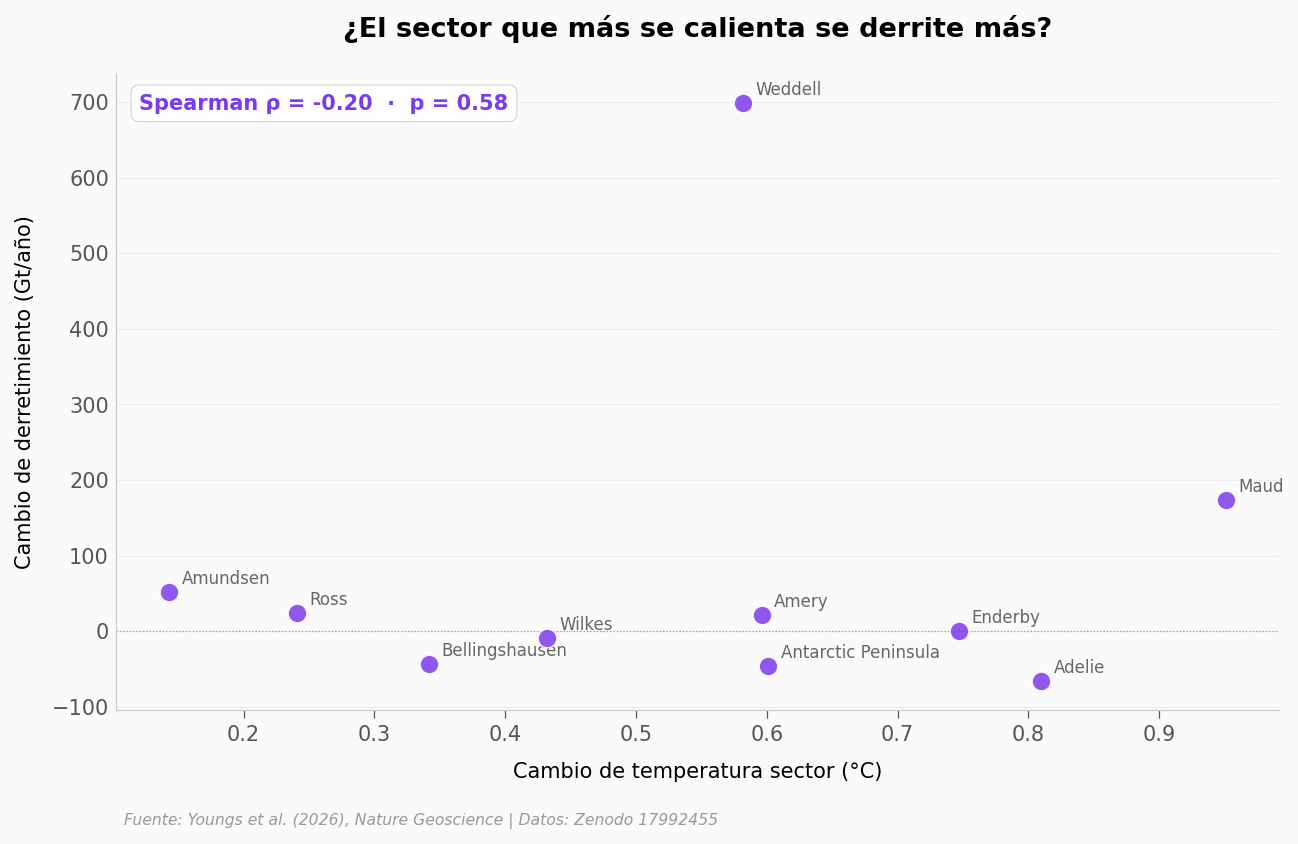


Spearman ρ = -0.200, p = 0.580
La correlación entre calentamiento y deshielo NO es trivial: la geometría
de cada cavidad (densa vs no densa) media la respuesta.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿coinciden temperatura y deshielo sector por sector?

import scipy.stats as stats

# Cruzar T y deshielo por sector (mismo orden)
df_cruce = melt[['sector','total_change_gt_yr']].merge(
    temp[['sector','total_change_c']], on='sector')

# Spearman (rank correlation, no asume normalidad)
rho, p = stats.spearmanr(df_cruce['total_change_gt_yr'],
                         df_cruce['total_change_c'])

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(df_cruce['total_change_c'], df_cruce['total_change_gt_yr'],
           color=COLOR_TOTAL, s=80, alpha=0.85,
           edgecolors='white', linewidths=0.7, zorder=5)

# Anotar cada sector
for _, row in df_cruce.iterrows():
    ax.annotate(row['sector'],
                (row['total_change_c'], row['total_change_gt_yr']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=8, color='#666666')

ax.axhline(0, color='#999999', linewidth=0.6, linestyle=':')
ax.set_xlabel('Cambio de temperatura sector (°C)', fontsize=10)
ax.set_ylabel('Cambio de derretimiento (Gt/año)', fontsize=10)
ax.set_title('¿El sector que más se calienta se derrite más?',
             fontsize=13, fontweight='bold', pad=18)
ax.text(0.02, 0.97,
        f'Spearman ρ = {rho:+.2f}  ·  p = {p:.2f}',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        color=COLOR_TOTAL, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.9))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/05_temperatura_vs_deshielo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nSpearman ρ = {rho:+.3f}, p = {p:.3f}')
print('La correlación entre calentamiento y deshielo NO es trivial: la geometría')
print('de cada cavidad (densa vs no densa) media la respuesta.')

## Fuentes

**Paper**: [Antarctic ice-shelf basal melt shaped by competing feedbacks](https://doi.org/10.1038/s41561-026-01975-6)  
*Nature Geoscience, 2026-05-15*

**Dataset canónico**: [mkyoungs/NG_SO_IceShelf: Files required to replicate results from Quantifying climatic forcing versus meltwater feedbacks on Antarctic ice shelf melt](https://zenodo.org/records/17992455)  
*Zenodo, 2025-12-19 — outputs de las simulaciones MITgcm bajo SSP5-8.5*

*14 afirmaciones verificadas contra estas fuentes*

---

**Datos originales:** [Zenodo: mkyoungs/NG_SO_IceShelf](https://zenodo.org/records/17992455) (CC-BY)
**Licencia notebook:** [CC-BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/)
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)